# Greek Protipa Exams Dataset: EDA & Samples

This notebook demonstrates how to load the **Greek Protipa Exams** dataset from Hugging Face, inspect samples, and perform Exploratory Data Analysis (EDA) using specialized utility functions.

In [263]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [264]:
import sys
import os
sys.path.append(os.path.abspath('../src'))
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from protipa_exams_dataset.eda_utils import display_qa
from dotenv import load_dotenv, find_dotenv
import numpy as np
import random

from protipa_exams_dataset.eda_utils import (
    print_sample, 
    display_samples,
    display_multimodal_samples, 
    plot_subject_dist,      
    plot_level_dist,        
    plot_format_dist,       
    plot_reference_dist,    
    plot_temporal_distribution,
    plot_points_distribution,


)

# Load environment variables
load_dotenv(find_dotenv())

repo_id = os.getenv("HF_REPO_ID")
token = os.getenv("HF_TOKEN")

print(f"Using Repository: {repo_id}")



Using Repository: PennyK98/test_newds


## 1. Load the Dataset
We load the `test` split, which contains the consolidated data.

In [265]:
dataset = load_dataset(repo_id, split="test", token=token, download_mode="force_redownload")
df = dataset.to_pandas()

print(f"✅ Dataset loaded. Total rows: {len(df)}")

README.md:   0%|          | 0.00/953 [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/17.4M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/1646 [00:00<?, ? examples/s]

✅ Dataset loaded. Total rows: 1646


## 2. Inspect Samples
We use the `display_samples` utility to look at a few random questions in detail.

In [279]:
#target_id = "math_lyc_2013_2_5.1", 'math_lyc_2013_2_6.3', 'math_lyc_2013_2_2_3', 'math_lyc_2016_1_10.2'
target_id = 'math_lyc_2022_1_50'
# print_sample(df, target_id)
#df[df['id'] == target_id]
all_ids = df['id'].to_list()
science_df = df[df['subject'].isin(['mathematics', 'physics'])]
all_science_ids = science_df['id'].tolist()

#random_id = random.choice( ['math_lyc_2016_1_10.2', 'math_lyc_2016_2_9.2', 'math_lyc_2016_0_9.1', 'math_lyc_2016_1_10.2', 'math_lyc_2016_2_9.2', 'math_lyc_2016_2_10.2'])
random_id = random.choice(all_science_ids)
# display_qa(df, random_id)

#target_id = "math_gym_2025_1_29"

display_qa(df, random_id)



In [169]:
display_samples(df, n=3, truncate=True)

id,subject,year,admission_level,question,input,image,choices,answer_text,answer_index
greek_language_lyc_2022_1_25,greek_language,2022,lyceum,Η φράση «έναν κόσμο ξεκουρντισμένο» σημαίνει:,"Κείμενο: Ημερολόγιο προσφυγιάς. «Αρχίσαμε να βαδίζουμε πιασμένοι απ’ το χέρι, κοντά ο ένας στον άλλ...",,• Α. έναν κόσμο αποσυντονισμένο• Β. έναν κόσμο απροκάλυπτο• Γ. έναν κόσμο αποτυχημένο• Δ. έναν κόσμο αποτρόπαιο,Α,0
math_lyc_2017_1_3,mathematics,2017,lyceum,Σε ορθογώνιο τρίγωνο ΑΒΓ η υποτείνουσα ΒΓ = 10 cm και η γωνία Β είναι 60ο. Το εμβαδόν του ΑΒΓ είναι:,,,• Α. $$\frac{25\sqrt{3}}{2}$$• Β. $$25\sqrt{3}$$• Γ. $$\frac{25}{2}$$• Δ. 25• Ε. $$50\sqrt{3}$$,Ε,4
greek_language_gym_2021_5_5,greek_language,2021,gymnasium,«Τα δειλινά» ποια ώρα της ημέρας είναι:,"Κείμενο: Γρ. Ξενόπουλος, «Αυτοβιογραφία» Στο βάθος του περιβολιού, κάτω από μια κληματαριά και πλάι...",,• Α. νωρίς το μεσημέρι• Β. νωρίς το απόγευμα• Γ. νωρίς το βράδυ• Δ. αργά το βράδυ,Γ,2


## 3. Multimodal Analysis (Samples with Images)
Let's specifically look at questions that include visual aids. We display them as a DataFrame first, then show the images.

id,subject,year,admission_level,question,input,image,choices,answer_text,answer_index
math_lyc_2016_1_9.2,mathematics,2016,lyceum,"Τρείς παράλληλες ευθείες $\epsilon_{1}$, $\epsilon_{2}$, $\epsilon_{3}$ διέρχονται από τις κορυφές Α, Β, Γ ενός τετραγώνου ΑΒΓΔ. Η απόσταση μεταξύ των $\epsilon_{1}$, $\epsilon_{2}$ είναι $AE=5$ cm και η απόσταση μεταξύ των $\epsilon_{2}$, $\epsilon_{3}$ είναι $BZ=7$ cm. Να αποδείξετε ότι τα τρίγωνα ΑΒΕ και ΒΓΖ είναι ίσα",,,,"Τα τρίγωνα ΑΒΕ και ΒΓΖ είναι ίσα, διότι: είναι ορθογώνια, $AB=B\Gamma$ (πλευρές τετραγώνου) και $\hat{\varphi}=\hat{\rho}$.",
math_gym_2022_1_15,mathematics,2022,gymnasium,Στο παρακάτω ραβδόγραμμα φαίνονται οι απαντήσεις όλων των παιδιών ενός σχολείου που απάντησαν στην ερώτηση: «πόσα στυλό έχετε μαζί σας σήμερα στο σχολείο;». Ποιο από τα επόμενα συμπεράσματα είναι λάθος με βάση το ραβδόγραμμα;,,,• Α. απάντησαν 55 παιδιά• Β. η απάντηση που έδωσαν τα περισσότερα παιδιά ήταν «3 στυλό»• Γ. τα παιδιά που απάντησαν ότι είχαν 1 ή 2 στυλό είναι όσα και τα παιδιά που απάντησαν ότι είχαν περισσότερα από 2 στυλό• Δ. τα παιδιά που απάντησαν ότι είχαν περισσότερα από 1 στυλό είναι όσα και τα παιδιά που απάντησαν ότι είχαν 1 ή 2 ή 3 στυλό,Γ,2
math_lyc_2020_1_29,mathematics,2020,lyceum,"Στα δύο σχήματα φαίνεται ο ίδιος κύκλος, με κέντρο το Κ, έχοντας άλλα γραμμοσκιασμένα μέρη σε κάθε σχήμα. Τα $K_{1}$ και $K_{2}$ είναι μέσα των ΒΚ και ΑΚ, αντίστοιχα. Τα γραμμοσκιασμένα μέρη είναι ημικύκλια. Αν οι γραμμοσκιασμένες επιφάνειες και στα δύο σχήματα μαζί, έχουν συνολικό εμβαδόν 6 $cm^{2}$ να βρείτε το εμβαδόν του κύκλου.",,,"• A. $8~cm^{2}$• B. $3,64~cm^{2}$• Г. $18~cm^{2}$• Δ. $16~cm^{2}$",Δ,3

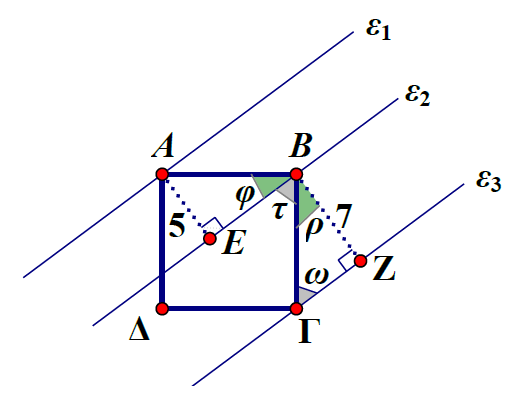
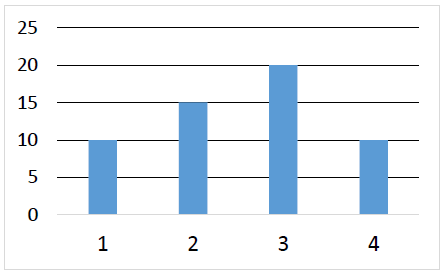
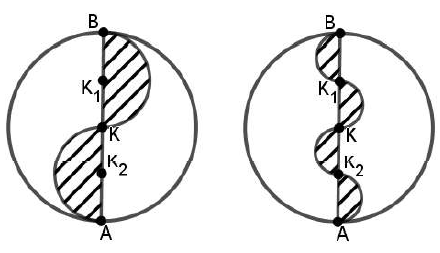

In [171]:
display_samples(df, n=3, prioritize_images=True)

## 4. Exploratory Data Analysis (EDA)

### 4.1 Distribution by Subject and Admission Level

,Subject,Count
0,greek_language,833
1,mathematics,714
2,religious studies,90
3,physics,9


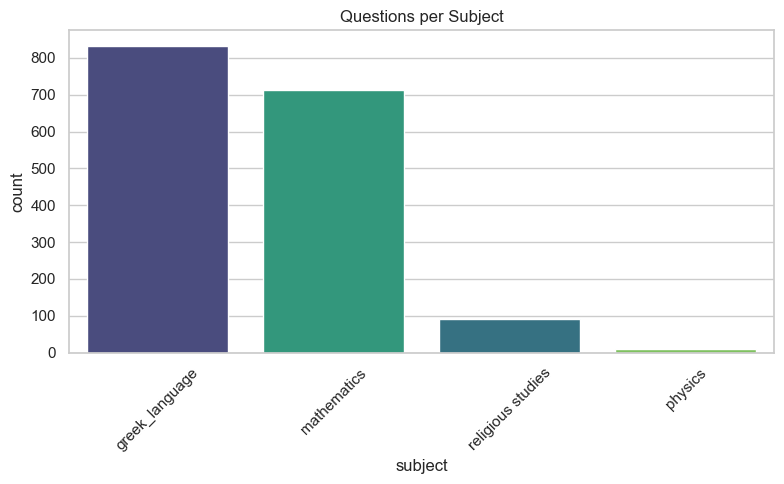

In [172]:

# Subject Distribution
fig_subj, df_subj = plot_subject_dist(df)
display(df_subj)
display(fig_subj)

,Admission Level,Count
0,gymnasium,838
1,lyceum,808


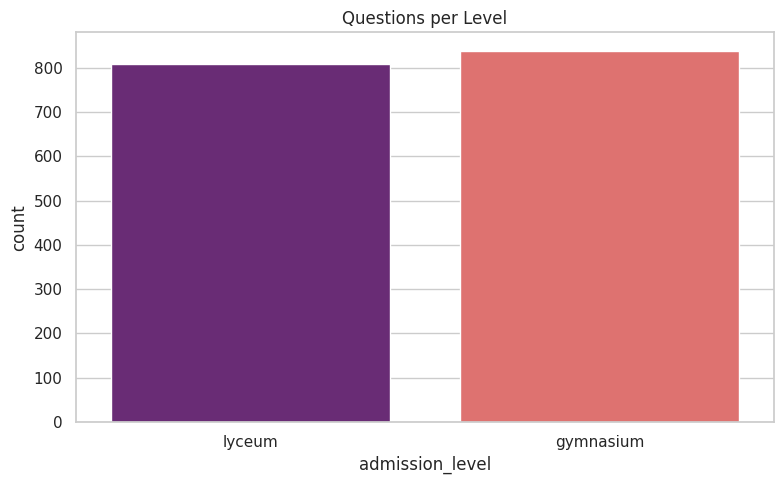

In [13]:
# Admission Level Distribution
fig_level, df_level = plot_level_dist(df)
display(df_level)
display(fig_level)

### 4.2 Distribution by Format and Reference Type

,Format,Count
0,multiple_choice,1268
1,open_ended,222
2,true_false,87
3,fill_in_the_gaps,65
4,matching,4


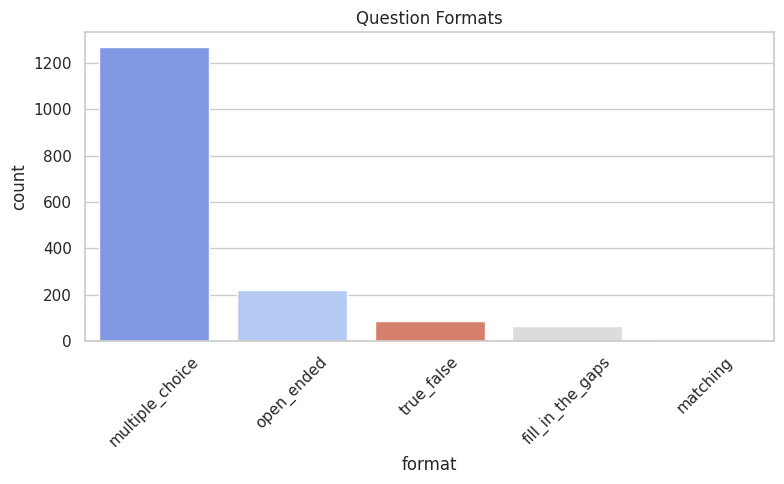

In [14]:
# Question Format Distribution
fig_format, df_format = plot_format_dist(df)
display(df_format)
display(fig_format)

,Reference,Count
0,none,742
1,passage,632
2,multimodal,270
3,table,2


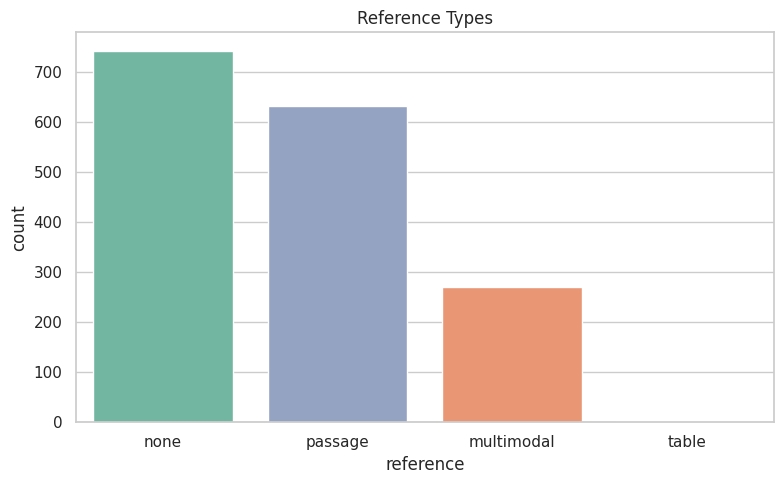

In [15]:
# Reference Type Distribution
fig_ref, df_ref = plot_reference_dist(df)
display(df_ref)
display(fig_ref)

### 4.3 Temporal Trends
How are questions distributed over the years per subject?

subject,greek_language,mathematics,physics,religious studies
year,,,,
2013,80.0,117.0,0.0,0.0
2014,0.0,8.0,9.0,0.0
2016,54.0,51.0,0.0,0.0
2017,65.0,37.0,0.0,0.0
2018,45.0,35.0,0.0,0.0
2019,40.0,24.0,0.0,0.0
2020,206.0,100.0,0.0,0.0
2021,103.0,85.0,0.0,0.0
2022,60.0,65.0,0.0,0.0


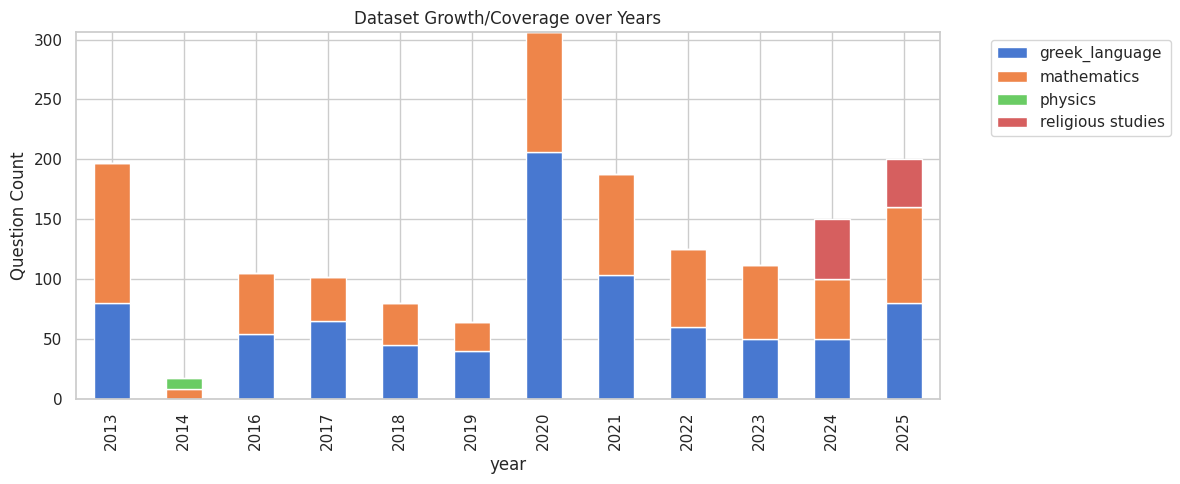

In [16]:
fig_temp, df_temp = plot_temporal_distribution(df)
display(df_temp)
display(fig_temp)

### 4.4 Point Values Analysis

Percentage of questions with point values assigned:
30.62%


,count,mean,std,min,25%,50%,75%,max
points,504.0,3.460317,1.907293,1.0,2.0,3.0,5.0,15.0


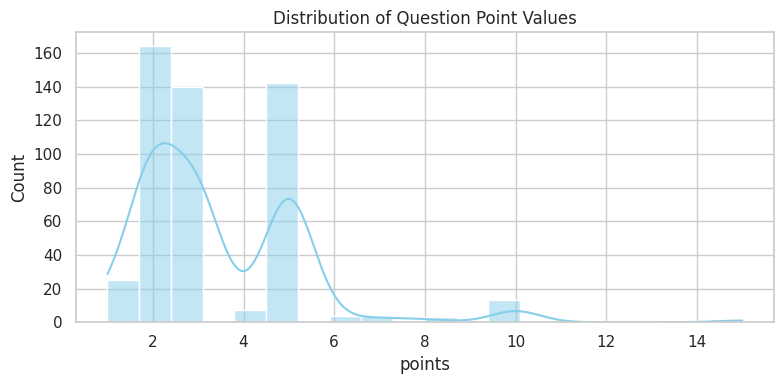

In [17]:
fig_points, df_points = plot_points_distribution(df)
display(df_points)
display(fig_points)

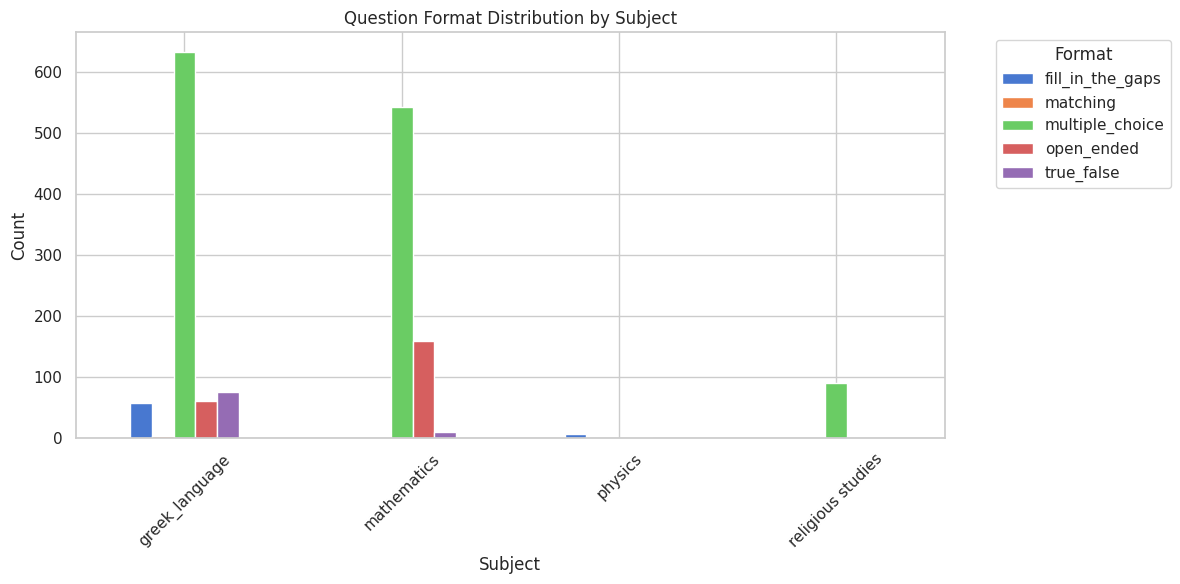

format,fill_in_the_gaps,matching,multiple_choice,open_ended,true_false
subject,,,,,
greek_language,58,4,634,61,76
mathematics,0,0,544,159,11
physics,7,0,0,2,0
religious studies,0,0,90,0,0


In [18]:
from protipa_exams_dataset.eda_utils import plot_format_by_subject
# Returns the matplotlib figure and the pivot table of counts
fig_fmt, df_fmt = plot_format_by_subject(df)
display(fig_fmt)
display(df_fmt)

### 4.5 Unique verification

In [19]:

# Create a temporary series where 'choices' are tuples so they can be hashed/compared
choices_hashable = df['choices'].apply(lambda x: tuple(x) if isinstance(x, (list, np.ndarray)) else x)

# 1. Total duplicates (Metadata + Choices)
# We find all standard hashable columns and manually include the converted choices
metadata_cols = [col for col in df.columns if df[col].apply(lambda x: not isinstance(x, (list, np.ndarray))).all()]
check_subset = metadata_cols + (['choices'] if 'choices' in df.columns else [])

# We use assign to temporarily hold the hashable choices for the check
total_duplicates = df.assign(choices=choices_hashable).duplicated(subset=check_subset).sum()
print(f"Total duplicate rows (Metadata + Choices): {total_duplicates}")

# 2. Check uniqueness of the 'id' column
if 'id' in df.columns:
    is_id_unique = df['id'].is_unique
    print(f"Is 'id' column unique? {is_id_unique}")
    if not is_id_unique:
        num_duplicates = df.duplicated('id').sum()
        print(f"Number of duplicate IDs: {num_duplicates}")


# 3. Check for rows with identical [Question + Choices + Input]
# This defines a "Semantic Duplicate" (same content, regardless of ID/Year)
subset_to_check = []
if 'question' in df.columns: subset_to_check.append('question')
if 'input' in df.columns:    subset_to_check.append('input')
subset_to_check.append('c_h') # This is our tuple-version of choices

content_duplicates = df.assign(c_h=choices_hashable).duplicated(subset=subset_to_check).sum()

print(f"Rows with identical content ({' + '.join([c if c!='c_h' else 'choices' for c in subset_to_check])}): {content_duplicates}")

# Optional: To actually see them
if content_duplicates > 0:
    print("\nDisplaying samples of content duplicates:")
    dup_rows = df.assign(c_h=choices_hashable)[df.assign(c_h=choices_hashable).duplicated(subset=subset_to_check, keep=False)]
    display(dup_rows.sort_values(by='question')[['id', 'subject', 'year', 'question', 'input']])

# 4. Check for nulls in critical columns
critical_cols = ['id', 'subject', 'admission_level', 'question']
existing_critical = [c for c in critical_cols if c in df.columns]
null_counts = df[existing_critical].isnull().sum()

if null_counts.sum() > 0:
    print("\nNull values in critical columns:")
    print(null_counts[null_counts > 0])
else:
    print(f"\n✅ No null values in critical columns ({', '.join(existing_critical)}).")

Total duplicate rows (Metadata + Choices): 0
Is 'id' column unique? True
Rows with identical content (question + input + choices): 0

✅ No null values in critical columns (id, subject, admission_level, question).


In [20]:
# Filter for duplicate questions
duplicate_questions_df = df[df.duplicated(subset=['question'], keep=False)].sort_values(by='question')

# Display with specific CSS for wrapping and column width
(duplicate_questions_df[['id', 'subject', 'year', 'question']]
 .style.set_properties(**{
     'text-align': 'left',
     'white-space': 'pre-wrap',  # Correctly handles newlines and wrapping
     'max-width': '600px',       # Limits width so it doesn't stretch the screen
     'vertical-align': 'top'
 }))

,id,subject,year,question
229,greek_language_gym_2022_1_3,greek_language,2022,Να βρείτε ποια επιλογή αποτελεί συνώνυμο της λέξης που είναι μαυρισμένη:
230,greek_language_gym_2022_1_4,greek_language,2022,Να βρείτε ποια επιλογή αποτελεί συνώνυμο της λέξης που είναι μαυρισμένη:
100,greek_language_gym_2023_1_14,greek_language,2023,"Ποια από τις παρακάτω προτάσεις αληθεύει, σύμφωνα με το κείμενο;"
1262,greek_language_gym_2021_6_1,greek_language,2021,"Ποια από τις παρακάτω προτάσεις αληθεύει, σύμφωνα με το κείμενο;"
215,greek_language_gym_2022_2_14,greek_language,2022,"Ποια από τις παρακάτω προτάσεις δεν αληθεύει, σύμφωνα με όσα αναφέρονται στο κείμενο;"
216,greek_language_gym_2022_2_15,greek_language,2022,"Ποια από τις παρακάτω προτάσεις δεν αληθεύει, σύμφωνα με όσα αναφέρονται στο κείμενο;"
1410,greek_language_lyc_2020_8_1,greek_language,2020,"Ποια από τις παρακάτω προτάσεις είναι σωστή, σύμφωνα με το νόημα του κειμένου;"
1573,greek_language_gym_2020_10_1,greek_language,2020,"Ποια από τις παρακάτω προτάσεις είναι σωστή, σύμφωνα με το νόημα του κειμένου;"
1586,greek_language_gym_2020_10_14,greek_language,2020,"Ποια από τις παρακάτω προτάσεις είναι σωστή, σύμφωνα με όσα αναφέρονται στο απόσπασμα;"
1587,greek_language_gym_2020_10_15,greek_language,2020,"Ποια από τις παρακάτω προτάσεις είναι σωστή, σύμφωνα με όσα αναφέρονται στο απόσπασμα;"


In [21]:
# 1. Find rows with literal \n (legacy escaped newlines)
literal_nl_mask = df['answer_text'].str.contains(r'\\n', regex=True, na=False)
literal_nl_ids = df[literal_nl_mask]['id'].tolist()
# 2. Find rows with stringified JSON lists ["...", "..."]
json_list_mask = df['answer_text'].str.startswith('[', na=False) & df['answer_text'].str.endswith(']', na=False)
json_list_ids = df[json_list_mask]['id'].tolist()
# 3. Find "True" multi-line answers (already using real newlines)
true_multiline_mask = df['answer_text'].str.contains('\n', na=False)
true_multiline_ids = df[true_multiline_mask]['id'].tolist()
print(f"📊 Rows with literal '\\n': {len(literal_nl_ids)}")
print(f"IDs: {literal_nl_ids[:10]} ...\n")
print(f"📦 Rows with stringified lists: {len(json_list_ids)}")
print(f"IDs: {json_list_ids[:10]} ...\n")
print(f"✅ Rows already using real newlines: {len(true_multiline_ids)}")
print(f"IDs: {true_multiline_ids[:10]} ...")

📊 Rows with literal '\n': 108
IDs: ['math_lyc_2017_1_9.1', 'math_lyc_2017_1_9.4', 'math_lyc_2017_1_10.1', 'math_gym_2017_1_9.1', 'math_gym_2017_1_9.2', 'math_gym_2017_1_10.1', 'math_gym_2017_1_10.2', 'math_gym_2019_1_9.2', 'math_gym_2019_1_10.1', 'math_gym_2018_1_9.1'] ...

📦 Rows with stringified lists: 38
IDs: ['math_lyc_2017_1_9.1', 'math_lyc_2017_1_10.2', 'greek_language_gym_2017_3_2', 'greek_language_gym_2017_3_6', 'greek_language_gym_2017_2_2', 'greek_language_lyc_2019_1_6', 'greek_language_gym_2018_1_8', 'phys_gym_2014_1_1', 'phys_gym_2014_1_2', 'phys_gym_2014_1_2_2'] ...

✅ Rows already using real newlines: 0
IDs: [] ...


In [36]:
from IPython.display import display, Markdown
import random

dataset = load_dataset(repo_id, split="test", token=token, download_mode="force_redownload")

# Select specific ID
target_id = "math_lyc_2025_2_31"
target_id = "math_lyc_2013_2_6.3"
target_id = "math_lyc_2016_1_10.2"
target_id = "math_lyc_2016_2_9.2"

subset = dataset.filter(lambda x: x["id"] == target_id)

if len(subset) > 0:
    sample = subset[0]
    
    # Construct Markdown output
    md_output = f"### ID: {sample['id']}\n"
    md_output += f"**Question:** {sample['question']}\n\n"

    # 1. Handle Multimodal Metadata
    if sample.get('image_description'):
        md_output += f"🖼️ **Image Description:** {sample['image_description']}\n\n"

    if sample.get('image_transcription'):
        md_output += f"📝 **Image Transcription:** {sample['image_transcription']}\n\n"

    # 2. Handle Choices
    if sample.get('choices'):
        md_output += "#### Choices:\n"
        correct_idx = sample.get('answer_index')
        for i, choice in enumerate(sample['choices']):
            marker = "✅" if i == correct_idx else "&nbsp;&nbsp;&nbsp;"
            md_output += f"- [{marker}] **{i}:** {choice}\n"
        md_output += f"\n**Correct Answer Index:** `{correct_idx}`"
    else:
        md_output += f"\n**Answer:** {sample['answer_text']}"

    # Render everything
    display(Markdown(md_output))
else:
    print(f"ID {target_id} not found in dataset.")

data/test-00000-of-00001.parquet:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/1646 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1646 [00:00<?, ? examples/s]

### ID: math_lyc_2016_2_9.2
**Question:** Μία βάρκα ξεκινάει από το λιμάνι Α, κινείται ανατολικά για 7 km μέχρι το σημείο Β, στη συνέχεια κινείται βόρεια για 9 km μέχρι το σημείο Γ, μετά πάλι ανατολικά για 8 km μέχρι το σημείο $\Delta$ και τέλος 11 km βόρεια μέχρι το λιμάνι Ε. Την επομένη, επιστρέφει από το Ε στο Α κινούμενη ευθύγραμμα. 
Να εξετάσετε αν, κατά την επιστροφή από το Ε στο Α, κινούμενη σε ευθεία γραμμή, η βάρκα θα περάσει από το σημείο Γ. (Δίνεται: $\sqrt{185}\approx13,6015$ και $\sqrt{130}\approx11,4018)$

🖼️ **Image Description:** The image displays a diagram of a path consisting of four line segments, representing movement on a map with cardinal directions.\nSegment $AB$: Horizontal line moving East, length $7$km. There is a right angle marker at point $B$.\nSegment $B\Gamma$: Vertical line moving North, length $9$km.\nSegment $\Gamma\Delta$: Horizontal line moving East, length $8$km. There is a right angle marker at point $\Delta$.\nSegment $\Delta E$: Vertical line moving North, length $11$km.


**Answer:** Πρώτη Λύση: Αν το Γ ήταν σημείο του τμήματος ΕΑ, τότε θα ίσχυε $EA=E\Gamma+A\Gamma$. Αλλά $E\Gamma+A\Gamma=25,0033\ne EA$. Άρα το ΕΑ δεν διέρχεται από το Γ.\n\nΔεύτερη Λύση: Αν υποτεθεί ότι η ΕΑ διέρχεται από το σημείο Γ, τότε οι παράλληλες ευθείες ΓΔ και ΑΚ τεμνόμενες από την ευθεία ΕΓΑ σχηματίζουν τις εντός εκτός και επί τα αυτά μέρη οξείες γωνίες φ, θ ίσες. Αυτό όμως δεν είναι αληθές, διότι $\epsilon\phi\varphi=\frac{9}{7}\ne\epsilon\varphi\theta=\frac{11}{8}.$\n\nΤρίτη Λύση: Θεωρώντας το σημείο Α ως αρχή των αξόνων, η ευθεία ΕΑ είναι η $y=4/3x$, το δε σημείο Γ έχει συντεταγμένες (7, 9). Αντικαθιστώντας τις συντεταγμένες του σημείου Γ στην εξίσωση της ευθείας βλέπουμε ότι δεν την επαληθεύει, άρα το σημείο Γ δεν ανήκει σε αυτήν.